<a href="https://colab.research.google.com/github/Prudhvilakshman1112/GEN-AI/blob/main/EXP_2_GAN_implementation_(MINIST).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏗️ Cell 1: Environment Setup & GPU Configuration
Purpose: Prepares the Colab virtual machine with necessary libraries and checks for hardware acceleration.

!pip install...: Installs the core deep learning engine (PyTorch) and progress bar utilities.

import torch: The main library for tensor math; the "engine" of the project.

device = torch.device(...):

Line Logic: This detects the NVIDIA GPU.

Contribution: It ensures the model runs on CUDA, which is required to train GANs in minutes rather than hours.

In [ ]:
# Install and import required libraries
!pip install torch torchvision matplotlib tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# ⚙️ Cell 2: Hyperparameters (MNIST Edition)
Purpose: Defines the constants that control the architecture and the speed of learning.

latent_dim = 100: The size of the "noise" vector; 100 random numbers that the AI uses to start a drawing.

channels = 1:

Crucial Change: We set this to 1 because MNIST is Grayscale (Black and White).

num_epochs = 20: Sets the number of training cycles. Because MNIST is simple, 20 cycles are enough to get sharp results.

beta1 / beta2: Stability parameters for the Adam optimizer that prevent the training from "crashing."

In [ ]:
# Hyperparameters
latent_dim = 100
img_size = 28     # MNIST native size is 28x28
channels = 1      # Grayscale for MNIST
batch_size = 64
lr = 0.0002
beta1 = 0.5
beta2 = 0.999
num_epochs = 20   # 20 epochs on MNIST will look better than 100 on CIFAR-10

# 🖼️ Cell 3: Data Loading & Grayscale Normalization
Purpose: Fetches the MNIST dataset and prepares it for the Discriminator.

transforms.Normalize([0.5], [0.5]):

Line Logic: Since there is only 1 channel, we only provide one value.

Contribution: This centers the pixel data between -1 and 1 to match the Generator's output range.

torchvision.datasets.MNIST(...): Downloads the handwritten digit dataset.

batch_size=128: Feeds 128 digits at a time to the GPU for efficient processing.

In [ ]:
# MNIST Transformation
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Single channel normalization
])

# Download and load MNIST
trainset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.12MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.29MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


# 🎨 Cell 4: The Generator (MNIST Artist)
Purpose: Defines the model that learns to turn random noise into a handwritten digit.

self.l1: The first layer that expands 100 numbers into a large array of data.

nn.Upsample: Increases the resolution of the image (e.g., from 14x14 to 28x28).

nn.Conv2d: The "brush" of the AI. It applies learned filters to create the curves of numbers.

nn.Tanh(): The final activation that ensures the pixels match the normalized data range.

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim, img_size, channels):
        super(Generator, self).__init__()
        self.init_size = img_size // 4
        self.l1 = nn.Sequential(nn.Linear(latent_dim, 128 * self.init_size ** 2))

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, channels, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.l1(z)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

# 🕵️ Cell 5: The Discriminator (The Detective)
Purpose: Defines the model that learns to tell the difference between a real digit and a forgery.

nn.Conv2d(..., stride=2): The "downsampling" layer. It shrinks the image while extracting key features.

nn.Dropout2d(0.25): Intentionally makes the detective "forget" some details.

Contribution: This prevents the Detective from becoming so perfect that the Artist can no longer learn.

nn.Sigmoid(): Converts the final score into a probability (0% to 100% real).

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, channels, img_size):
        super(Discriminator, self).__init__()

        def discriminator_block(in_filters, out_filters, bn=True):
            block = [nn.Conv2d(in_filters, out_filters, 3, 2, 1),
                    nn.LeakyReLU(0.2, inplace=True),
                    nn.Dropout2d(0.25)]
            if bn: block.append(nn.BatchNorm2d(out_filters, 0.8))
            return block

        self.model = nn.Sequential(
            *discriminator_block(channels, 16, bn=False),
            *discriminator_block(16, 32),
            *discriminator_block(32, 64),
        )

        ds_size = img_size // 2 ** 3 # Adjusted for 28x28
        self.adv_layer = nn.Sequential(
            nn.Linear(64 * 4 * 4, 1), # Flattened size for 28x28 input
            nn.Sigmoid()
        )

    def forward(self, img):
        out = self.model(img)
        out = out.view(out.shape[0], -1)
        validity = self.adv_layer(out)
        return validity

# ⚔️ Cell 6: The Training Logic (The "Battle" Function)
Purpose: This cell defines the master function where the two networks compete. This is the "brain" of the training process.

def train_gan(...):

Line Logic: Defines the function that handles the epoch loops and weight updates.

valid / fake labels:

Purpose: Creates the "Answer Key." valid (1s) represents real images; fake (0s) represents the AI's forgeries.

optimizer_G.zero_grad() / optimizer_D.zero_grad():

Purpose: Clears the math history (gradients) from the previous batch so the model doesn't get confused.

g_loss = adversarial_loss(discriminator(gen_imgs), valid):

The "Lie": The Generator shows a fake image to the Discriminator but tells the scoring system "this should have been a 1 (Real)." This forces the Generator to improve.

gen_imgs.detach():

Purpose: Technical isolation.

Line Logic: It ensures that when we train the Discriminator, we do not accidentally change the Generator's weights. We only want the Detective to learn in this step.

save_image(...):

Purpose: Every 5 epochs, it saves a grid of 25 images to your folder so you can watch the numbers become clearer over time.

In [ ]:
def train_gan(generator, discriminator, trainloader, num_epochs, latent_dim):
    # Lists to store losses for plotting later
    g_losses = []
    d_losses = []

    for epoch in range(num_epochs):
        # tqdm creates the visual progress bar for each epoch
        for i, (imgs, _) in enumerate(tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}")):

            # Create ground truth labels (1 for Real images, 0 for Fake images)
            valid = torch.ones(imgs.size(0), 1, device=device)
            fake = torch.zeros(imgs.size(0), 1, device=device)

            # Move real images from dataset to the GPU
            real_imgs = imgs.to(device)

            # ---------------------
            #  1. Train Generator
            # ---------------------
            optimizer_G.zero_grad() # Clear previous math history

            # Generate fake images from random noise
            z = torch.randn(imgs.size(0), latent_dim, device=device)
            gen_imgs = generator(z)

            # Generator wants Discriminator to think these fakes are 'valid' (1)
            g_loss = adversarial_loss(discriminator(gen_imgs), valid)

            g_loss.backward() # Calculate errors
            optimizer_G.step() # Update Generator's weights

            # ---------------------
            #  2. Train Discriminator
            # ---------------------
            optimizer_D.zero_grad() # Clear previous math history

            # Calculate how well the Discriminator identifies real images
            real_loss = adversarial_loss(discriminator(real_imgs), valid)

            # Calculate how well it identifies fake images (detached from Generator's math)
            fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)

            # Average the two losses
            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward() # Calculate errors
            optimizer_D.step() # Update Discriminator's weights

            # Store values for the loss graph
            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())

        # Save a snapshot of progress every 5 epochs
        if (epoch + 1) % 5 == 0:
            # We use 'mnist_images' because we are now using the MNIST dataset
            save_image(gen_imgs.data[:25], f"mnist_images/epoch_{epoch+1}.png", nrow=5, normalize=True)
            print(f"Epoch {epoch+1}: D loss: {d_loss.item():.4f}, G loss: {g_loss.item():.4f}")

    return g_losses, d_losses

# 🧪 Cell 7: Model Initialization & Execution
Purpose: This cell creates the actual model objects and triggers the training function defined in the previous cell.

generator = Generator(...).to(device):

Line Logic: Creates the Artist and moves it to the GPU.

discriminator = Discriminator(...).to(device):

Line Logic: Creates the Detective and moves it to the GPU.

adversarial_loss = nn.BCELoss():

Purpose: The Binary Cross Entropy loss function. It measures how far the Discriminator's guess is from the truth.

optim.Adam(...):

Line Logic: Sets up the specific mathematical engines (optimizers) for both networks using the learning rate and betas from Cell 2.

os.makedirs("mnist_images", ...):

Purpose: Creates the physical directory where your progress snapshots will be stored.

g_losses, d_losses = train_gan(...):

Purpose: Starts the actual training loop. Run this cell to begin the AI learning process.

In [ ]:
# Initialize
generator = Generator(latent_dim, img_size, channels).to(device)
discriminator = Discriminator(channels, img_size).to(device)
adversarial_loss = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))

os.makedirs("mnist_images", exist_ok=True)

# Run the training loop (using the train_gan function from your original code)
# Since the training function is already defined in your logic, call it here:
g_losses, d_losses = train_gan(generator, discriminator, trainloader, num_epochs, latent_dim)

Epoch 5/20: 100%|██████████| 938/938 [00:25<00:00, 36.42it/s]


Epoch 5: D loss: 0.6961, G loss: 0.7145


Epoch 10/20: 100%|██████████| 938/938 [00:25<00:00, 36.87it/s]


Epoch 10: D loss: 0.7262, G loss: 0.6686


Epoch 15/20: 100%|██████████| 938/938 [00:25<00:00, 36.29it/s]


Epoch 15: D loss: 0.7073, G loss: 0.6997


Epoch 20/20: 100%|██████████| 938/938 [00:25<00:00, 37.30it/s]

Epoch 20: D loss: 0.6636, G loss: 0.7978


# 📈 Cell 8: Visualization & Model Export
Purpose: This cell graphs the training history and saves the final trained "brains" of your AI.

plt.plot(g_losses / d_losses):

Purpose: Draws the "Battle Graph."

Line Logic: If the lines are moving up and down together, your GAN is healthy.

plt.title("MNIST GAN Training Loss"):

Purpose: Labels the graph specifically for the MNIST dataset.

torch.save(generator.state_dict(), 'mnist_generator.pth'):

Purpose: Exports the learned intelligence of the Artist.

Use-case: You can download this file. Tomorrow, you can load it and generate numbers instantly without training again.

torch.save(discriminator.state_dict(), 'mnist_discriminator.pth'):

Purpose: Saves the learned intelligence of the Detective.

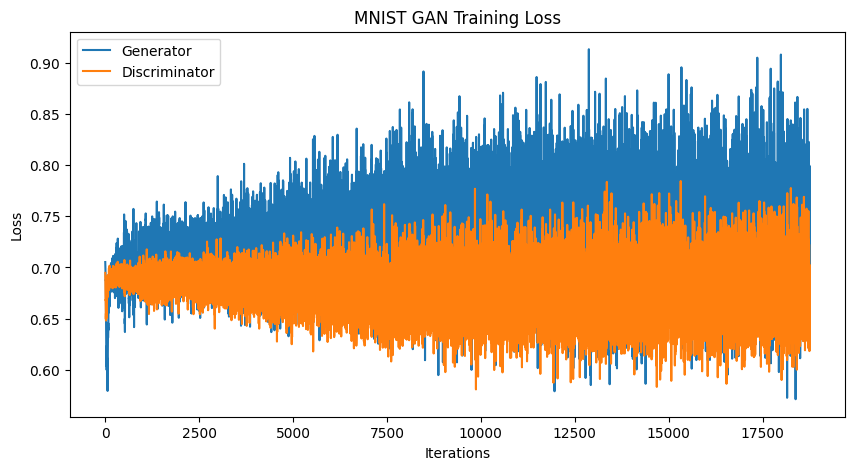

MNIST Models saved successfully in the files sidebar!


In [ ]:
# Cell 10 & 12: Visualization and Model Export
plt.figure(figsize=(10,5))
# Plotting the error history of the Artist
plt.plot(g_losses, label="Generator")
# Plotting the error history of the Detective
plt.plot(d_losses, label="Discriminator")

plt.title("MNIST GAN Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Exporting the weights (learned intelligence)
torch.save(generator.state_dict(), 'mnist_generator.pth')
torch.save(discriminator.state_dict(), 'mnist_discriminator.pth')
print("MNIST Models saved successfully in the files sidebar!")

# 🚀 Cell 9: Final Inference (Generate Fresh Digits)
Purpose: Now that the AI is trained, this cell lets you see its best "drawings."

generator.eval():

Purpose: Switches the Artist to "show" mode. It turns off training-only features like Dropout.

with torch.no_grad()::

Purpose: Disables math tracking. Since we aren't learning anymore, this makes the generation much faster.

(generator(z).cpu() + 1) / 2:

Purpose: Denormalization.

Line Logic: Converts the AI's internal numbers ( -1 to 1) back into standard pixel values (0 to 1) so we can see them.

cmap='gray':

Purpose: Tells Matplotlib to display the images in Black and White (Grayscale) to match the MNIST style.

generate_fresh_batch():

Purpose: Calls the function to display 10 brand-new digits that have never existed before.

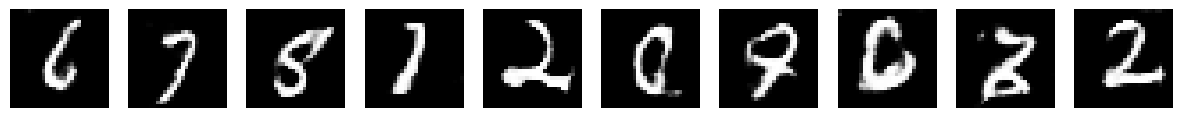

In [ ]:
def generate_fresh_batch(num=10):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(num, latent_dim, device=device)
        gen_imgs = (generator(z).cpu() + 1) / 2 # Denormalize
        fig, axes = plt.subplots(1, num, figsize=(15, 3))
        for i in range(num):
            axes[i].imshow(gen_imgs[i].squeeze(), cmap='gray') # Grayscale map
            axes[i].axis('off')
        plt.show()

generate_fresh_batch()


🎨 Generating 5 new handwritten digits...


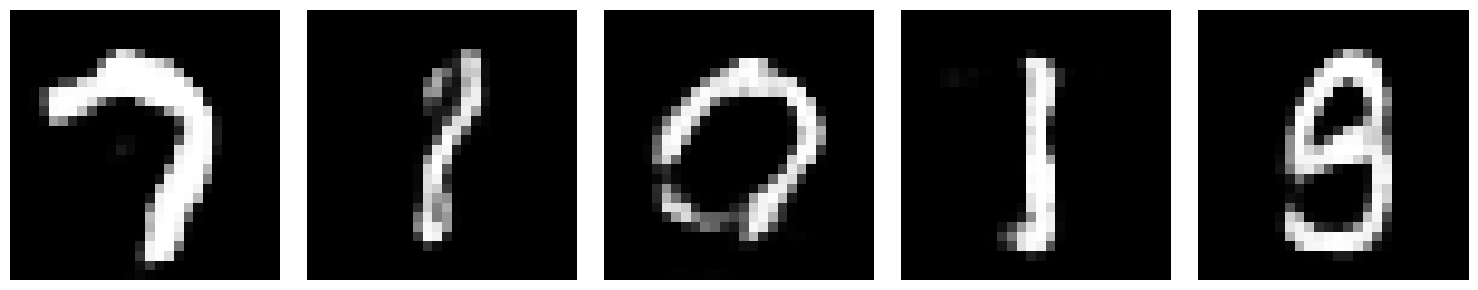

KeyboardInterrupt: Interrupted by user

In [ ]:
# Cell 10: Interactive Digit Generation
def interactive_generation():
    """
    Interactive function to generate specific numbers of digits and save them.
    """
    try:
        num_images = int(input("How many digits would you like to generate? (1-10): "))
        num_images = min(max(num_images, 1), 10)  # Limits input between 1 and 10
    except ValueError:
        print("Invalid input. Generating 5 images by default.")
        num_images = 5

    print(f"\n🎨 Generating {num_images} new handwritten digits...")

    generator.eval() # Set to evaluation mode
    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        gen_imgs = generator(z).cpu()

        # Denormalize from [-1, 1] to [0, 1] for display
        gen_imgs = (gen_imgs + 1) / 2

        # Display the images
        fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
        if num_images == 1: axes = [axes] # Handle single image case

        for i in range(num_images):
            # squeeze() removes the channel dimension (1) for grayscale display
            axes[i].imshow(gen_imgs[i].squeeze(), cmap='gray')
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

        # Option to save the specific digits to your folder
        save_option = input("Do you want to save these digits to the 'mnist_images' folder? (y/n): ").lower()
        if save_option == 'y':
            for i in range(num_images):
                save_image(gen_imgs[i], f"mnist_images/interactive_digit_{i+1}.png")
            print("✅ Digits saved successfully!")

# Run the interactive tool
interactive_generation()